In [1]:
import math

from itertools import product

import matplotlib.pyplot as plt
import pandas as pd
import torch
from scipy.optimize import root_scalar
from torch.distributions import Normal

This notebook reproduces some results from the paper "Empirical Evaluation of Biased Methods for Alpha Divergence Minimization" by Geffner and Domke (2021).


```bibtex
@inproceedings{
    geffner2021empirical,
    title={Empirical Evaluation of Biased Methods for Alpha Divergence Minimization},
    author={Tomas Geffner and Justin Domke},
    booktitle={Third Symposium on Advances in Approximate Bayesian Inference},
    year={2021},
    url={https://openreview.net/forum?id=ihUcld16Mpu}
}
```

Let the target distribution be

$$p(x) = \mathcal{N}(\bm{0}, \Sigma_p)$$

with $\Sigma_p=\text{diag}(\sigma_1^2, \dots, \sigma_d^2)$. Variance components grow linearly from $\sigma_1^2 =0.2$ to $\sigma_d^2 = 10$. Simulations are run for $d \in \{10,100,10000\}$.

The variational distribution is a mean-zero isotropic Gaussian distribution
$$q(x) = \mathcal{N}(\bm{0}, \sigma^2\bm{I}),$$

where $\sigma$ is the parameter when we need to optimize.

In [2]:
_ = torch.manual_seed(0)
torch.set_default_dtype(torch.float64)

In [3]:
def ELBO(q: Normal, p: Normal, samples: tuple =(1,)):
    x = q.rsample(samples)
    log_q = q.log_prob(x)
    log_p = p.log_prob(x)
    return (log_p - log_q).sum(-1).mean()

def KLpqMC(q: Normal, p: Normal, samples: tuple):
    # Naive Monte Carlo estimator
    x = p.sample(samples)
    log_q = q.log_prob(x)
    log_p = p.log_prob(x)
    return torch.sum(log_p - log_q, dim=-1).mean()

def KLpqSNIS(q: Normal, p: Normal, samples: tuple):
    x = q.sample(samples)
    log_q = q.log_prob(x)
    
    with torch.no_grad():
        log_p = p.log_prob(x)
        log_w = log_p - log_q.detach()
        w = torch.exp(log_w - log_w.max())
        w_norm = w / w.sum()

    return torch.sum(w_norm * (log_p.detach() - log_q))

def KLpqSTL(q: Normal, p: Normal, samples: tuple):
    # Stick the landing estimator
    d = q.batch_shape[0]
    x = q.rsample(samples)
    log_p = p.log_prob(x)
    
    with torch.no_grad():
        log_q = q.log_prob(x)
        log_w = (log_p.detach() - log_q.detach()).sum(-1)
        w = torch.exp(log_w - log_w.max())
        w_norm = w / w.sum()

    q2 = torch.distributions.Normal(torch.zeros(d), q.scale.detach())
    log_q = q2.log_prob(x)

    return -torch.sum(w_norm * (log_p - log_q).sum(-1))

def KLpqDREP(q: Normal, p: Normal, samples: tuple):
    # Doubly reparameterization estimator
    d = q.batch_shape[0]
    x = q.rsample(samples)
    log_p = p.log_prob(x)
    
    with torch.no_grad():
        log_q = q.log_prob(x)
        log_w = (log_p.detach() - log_q.detach()).sum(-1)
        w = torch.exp(log_w - log_w.max())
        w_norm = (w / w.sum())**2
    
    q2 = torch.distributions.Normal(torch.zeros(d), q.scale.detach())
    log_q = q2.log_prob(x)

    return -torch.sum(w_norm * (log_p - log_q).sum(-1))

def KLpqRenyi(q: Normal, p: Normal, samples: tuple, alpha=0.5):
    d = q.batch_shape[0]
    x = q.rsample(samples)
    log_p = p.log_prob(x)
    log_q = q.log_prob(x)

    with torch.no_grad():
        log_w = (log_p.detach() - log_q.detach()).sum(-1)
        w = torch.exp(log_w - log_w.max())**(1-alpha)
        w_norm = w / w.sum()

    return -torch.sum(w_norm * (log_p - log_q).sum(-1))

def advi(fn, d, log_sigma, maximize, grad_samples=(1,), iterations = 5000, lr=0.01):
    optimizer = torch.optim.Adam((log_sigma,), lr=lr, maximize=maximize)
    lr_lambda = lambda epoch: 1.0/math.sqrt(epoch+1)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
    
    # sigma = (0.2 + 9.8* (torch.arange(d)+1)/d).sqrt()
    sigma = torch.linspace(0.2, 10.0, d).sqrt()
    p = torch.distributions.Normal(torch.zeros(d), sigma)
    q = torch.distributions.Normal(torch.zeros(d), log_sigma.exp().expand((d,)))
    
    losses = [fn(q, p, (1000,)).detach()]
    sigmas = [log_sigma.detach().exp().clone()]
    # print(f"{0} LOSS: {losses[-1]}")

    for i in range(1, iterations+1):
        q = torch.distributions.Normal(torch.zeros(d), log_sigma.exp()*torch.ones(d))
        loss = fn(q, p, grad_samples)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        sigmas.append(log_sigma.detach().exp().clone())

        if i % 1000 == 0:
            with torch.no_grad():
                losses.append(fn(q, p, (1000,)))
                # print(f"{i} LOSS: {losses[-1]}")
    
    q = torch.distributions.Normal(torch.zeros(d), log_sigma.exp()*torch.ones(d))
    return q, losses, torch.cat(sigmas)

In [4]:
elbo = {}
for d in 10, 100, 1000, 10000:
    log_sigma = torch.tensor([math.log(3.0)], requires_grad=True)
    q, elbos, sigmas = advi(ELBO, d, log_sigma, True, grad_samples=(1,), iterations=10000)
    elbo[f"{d}"] = sigmas**2
    print(f"ELBO {d} {elbos[-1]} {sigmas[-1]**2}")

ELBO 10 -5.093404884581492 1.7073573861287799
ELBO 100 -26.27322604319798 2.38484017916424
ELBO 1000 -234.86970249890805 2.493503412888869
ELBO 10000 -2323.4383847657664 2.499935082315744


In [5]:
naive = {}
for d, k in product([10, 100, 1000], [10, 100, 1000]):
    log_sigma = torch.tensor([math.log(3.0)], requires_grad=True)
    q, losses, sigmas = advi(KLpqMC, d, log_sigma, False, grad_samples=(k,), iterations=10000)
    naive[f"{d}-{k}"] = sigmas**2
    print(f"Approx {d}-{k} {losses[-1]} {sigmas[-1]**2}")

Approx 10-10 1.9207537213367867 5.112398984317418
Approx 10-100 1.9494478626410154 5.088719171099534
Approx 10-1000 1.8847214602510762 5.091964353944714
Approx 100-10 12.960759738918478 5.102295752578593
Approx 100-100 12.94693418821728 5.099001531279548
Approx 100-1000 13.026702476685504 5.106816767047831
Approx 1000-10 123.99766498987749 5.107254511280761
Approx 1000-100 123.90568577733735 5.094083758171498
Approx 1000-1000 123.72988637913113 5.100814451725247


In [6]:
rws = {}
for d, k in product([10, 100, 1000], [10, 100, 1000]):
    log_sigma = torch.tensor([math.log(3.0)], requires_grad=True)
    q, losses, sigmas = advi(KLpqSNIS, d, log_sigma, False, grad_samples=(k,), iterations=10000)
    rws[f"{d}-{k}"] = sigmas**2
    print(f"RWS {d}-{k} {losses[-1]} {sigmas[-1]**2}")

RWS 10-10 0.19493437795175267 5.0013970273710715
RWS 10-100 0.18400605563346908 5.055382070238074
RWS 10-1000 0.21479222932332573 5.0826037454036115
RWS 100-10 0.12721154185340186 5.097909568976541
RWS 100-100 0.12671045760599847 5.1046383787174445
RWS 100-1000 0.12960413613273356 5.08684377651161
RWS 1000-10 0.12419066234726411 5.0975725952642055
RWS 1000-100 0.12380856831523421 5.1055647654950285
RWS 1000-1000 0.12549925116721614 5.0988936523920945


In [7]:
stl = {}
for d, k in product([10, 100, 1000], [10, 100, 1000]):
    log_sigma = torch.tensor([math.log(3.0)], requires_grad=True)
    q, losses, sigmas = advi(KLpqSTL, d, log_sigma, False, grad_samples=(k,), iterations=10000)
    stl[f"{d}-{k}"] = sigmas**2
    print(f"STL {d}-{k} {losses[-1]} {sigmas[-1]**2}")

STL 10-10 -1.8343388016521402 4.022508534586973
STL 10-100 -2.344529667982261 4.875222600788385
STL 10-1000 -1.4965482357958748 5.051832277848334
STL 100-10 0.9410349483415016 3.2540988142505323
STL 100-100 -3.1703576906160666 3.741962048751564
STL 100-1000 1.1086895632283418 4.106273301708523
STL 1000-10 148.83803097244294 2.7504321783031624
STL 1000-100 142.90435350918906 2.913044026703807
STL 1000-1000 129.91445574482117 3.0334926285583497


In [8]:
drep = {}
for d, k in product([10, 100, 1000], [10, 100, 1000]):
    log_sigma = torch.tensor([math.log(3.0)], requires_grad=True)
    q, losses, sigmas = advi(KLpqDREP, d, log_sigma, False, grad_samples=(k,), iterations=10000)
    drep[f"{d}-{k}"] = sigmas**2
    print(f"DREP {d}-{k} {losses[-1]} {sigmas[-1]**2}")

DREP 10-10 -0.027475268670086733 4.426684540962336
DREP 10-100 -0.02069334666871798 5.965178415120257
DREP 10-1000 -0.02211912319851074 6.39231159038075
DREP 100-10 0.14387847078200483 3.269926990875748
DREP 100-100 -1.8098334325013605 3.817751829283683
DREP 100-1000 -1.1608270747934883 4.232898105743734
DREP 1000-10 50.78732679711201 2.7483279212145426
DREP 1000-100 143.52628143627823 2.9169082050411417
DREP 1000-1000 134.26884748622194 3.040348485249625


In [9]:
renyi = {}
for d, k in product([10, 100, 1000], [10, 100, 1000]):
    log_sigma = torch.tensor([math.log(3.0)], requires_grad=True)
    q, losses, sigmas = advi(KLpqRenyi, d, log_sigma, False, grad_samples=(k,), iterations=10000)
    renyi[f"{d}-{k}"] = sigmas**2
    print(f"Renyi {d}-{k} {losses[-1]} {sigmas[-1]**2}")

Renyi 10-10 -0.436096123324915 3.6475835604894997
Renyi 10-100 -0.6246006210494573 3.888667611564379
Renyi 10-1000 -0.4185543357571868 3.897048977273102
Renyi 100-10 -0.4921323484699683 3.23881228275268
Renyi 100-100 -0.27809809153730636 3.707836840638366
Renyi 100-1000 -4.446413521714738 3.9755890614604636
Renyi 1000-10 110.28265042582326 2.7478953714544314
Renyi 1000-100 131.896437115311 2.9247743757373037
Renyi 1000-1000 138.2307955380232 3.0477981816737274


In [10]:
def min_klqp(variances: torch.Tensor) -> torch.Tensor:
    d = variances.shape[0]
    return d/(1/variances).sum()

def min_klpq(variances: torch.Tensor) -> torch.Tensor:
    d = variances.shape[0]
    A = variances.sum()  # sum σ_i^2
    log_det_p = torch.log(variances).sum()
    var_star = A / d
    kl = 0.5 * (
        d * torch.log(var_star)
        - log_det_p
    )
    return var_star

def min_renyi(variances: torch.Tensor) -> torch.Tensor:
    def fn(sigma_sq):
        if sigma_sq <= 0:
            return torch.inf
        denom = torch.sum(1.0 / (variances + sigma_sq))
        return sigma_sq - d / (2 * denom)
    
    result = root_scalar(fn, bracket=[1e-8, 1e4], method='brentq')
    return torch.tensor(result.root)

def min_chi2(variances: torch.Tensor, tol: float = 1e-9, max_iter: int = 200) -> torch.Tensor:

    def fn(v: torch.Tensor) -> torch.Tensor:
        return ((v - variances) / (2.0 * v - variances)).sum()

    lam_max = variances.max()

    # lower bound: just inside the valid domain
    lo = lam_max / 2.0 * (1 + 1e-10)

    # upper bound: grow exponentially until f > 0
    hi = lam_max
    while fn(hi) <= 0:
        hi *= 2.0

    for _ in range(max_iter):
        mid = (lo + hi) / 2.0
        if fn(mid) < 0:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break

    return (lo + hi) / 2.0

In [11]:
klpqs = []
klqps = []
renyis = []
chi2s = []
dimensions = (10, 100, 1000, 10000, 100000)
for d in dimensions:
    v = torch.linspace(0.2, 10.0, d)
    klpqs.append(min_klpq(v).item())
    klqps.append(min_klqp(v).item())
    renyis.append(min_renyi(v).item())
    chi2s.append(min_chi2(v).item())

df = pd.DataFrame({r"KL(p|q)": klpqs,
                   "KL(q|p)": klqps,
                   "Renyi": renyis,
                   r"chi^2(p|q)": chi2s},
                   index=pd.Index(dimensions, name="dimension"))
print(df)


           KL(p|q)   KL(q|p)     Renyi  chi^2(p|q)
dimension                                         
10             5.1  1.356827  3.885374    6.525467
100            5.1  2.365689  4.135671    6.338586
1000           5.1  2.491546  4.157133    6.320585
10000          5.1  2.503747  4.159248    6.318793
100000         5.1  2.504963  4.159459    6.318614


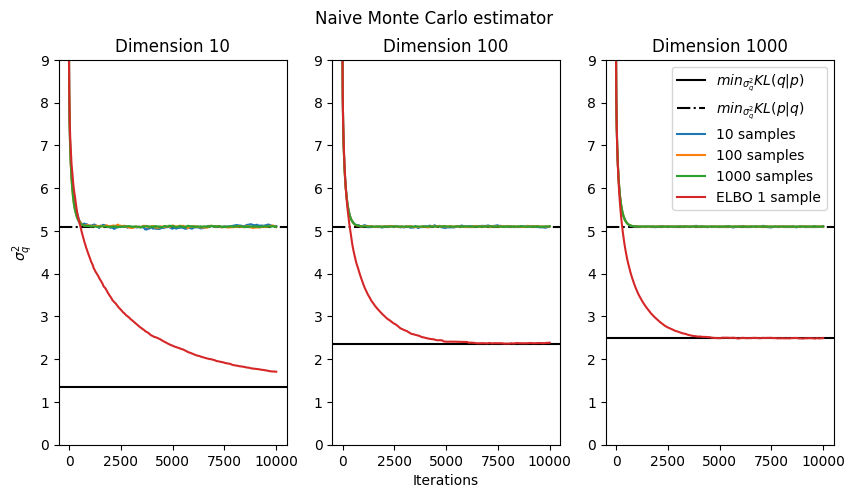

In [12]:
f, axes = plt.subplots(1, 3, figsize=(10,5))
f.suptitle("Naive Monte Carlo estimator")
for i, d in enumerate((10, 100, 1000)):
    # v = 0.2 + 9.8 * (torch.arange(d)+1)/d
    v = torch.linspace(0.2, 10.0, d)
    axes[i].axhline(y=min_klqp(v), color='black', linestyle='-', label=r"$min_{\sigma_q^2} KL(q|p)$")
    axes[i].axhline(y=min_klpq(v), color='black', linestyle='-.', label=r"$min_{\sigma_q^2} KL(p|q)$")
    
    for j, k in enumerate((10, 100, 1000)):
        axes[i].plot(naive[f"{d}-{k}"], label=f"{k} samples")
    axes[i].plot(elbo[f"{d}"], label=f"ELBO 1 sample")
    axes[i].set_ylim(0, 9)
    axes[i].set_title(f"Dimension {d}")
axes[0].set_ylabel(r"$\sigma^2_q$")
axes[1].set_xlabel("Iterations")
plt.legend()
plt.show()

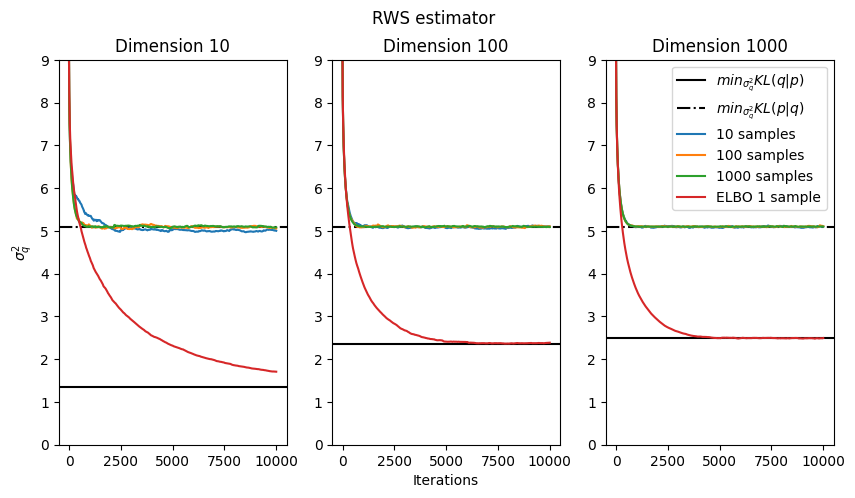

In [13]:
pairs = [tuple(map(int, key.split("-"))) for key in rws.keys()]

ds = sorted({d for d, _ in pairs})
ks = sorted({k for _, k in pairs})

f, axes = plt.subplots(1, len(ds), figsize=(10,5))
f.suptitle("RWS estimator")
for i, d in enumerate(ds):
    # v = 0.2 + 9.8 * (torch.arange(d)+1)/d
    v = torch.linspace(0.2, 10.0, d)
    axes[i].axhline(y=min_klqp(v), color='black', linestyle='-', label=r"$min_{\sigma_q^2} KL(q|p)$")
    axes[i].axhline(y=min_klpq(v), color='black', linestyle='-.', label=r"$min_{\sigma_q^2} KL(p|q)$")
    
    for j, k in enumerate(ks):
        axes[i].plot(rws[f"{d}-{k}"], label=f"{k} samples")
    axes[i].plot(elbo[f"{d}"], label=f"ELBO 1 sample")
    axes[i].set_ylim(0, 9)
    axes[i].set_title(f"Dimension {d}")
axes[0].set_ylabel(r"$\sigma^2_q$")
axes[1].set_xlabel("Iterations")
plt.legend()
plt.show()

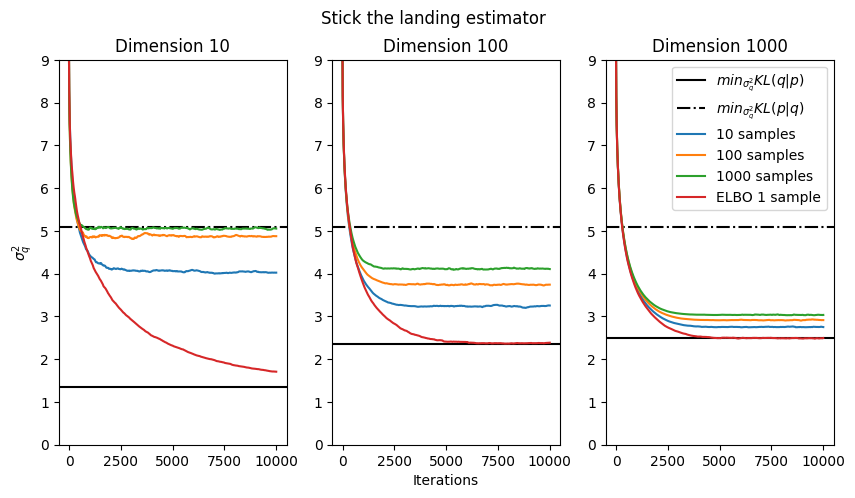

In [14]:
pairs = [tuple(map(int, key.split("-"))) for key in stl.keys()]

ds = sorted({d for d, _ in pairs})
ks = sorted({k for _, k in pairs})

f, axes = plt.subplots(1, len(ds), figsize=(10,5))
f.suptitle("Stick the landing estimator")
for i, d in enumerate(ds):
    # v = 0.2 + 9.8 * (torch.arange(d)+1)/d
    v = torch.linspace(0.2, 10.0, d)
    axes[i].axhline(y=min_klqp(v), color='black', linestyle='-', label=r"$min_{\sigma_q^2} KL(q|p)$")
    axes[i].axhline(y=min_klpq(v), color='black', linestyle='-.', label=r"$min_{\sigma_q^2} KL(p|q)$")
    
    for j, k in enumerate(ks):
        axes[i].plot(stl[f"{d}-{k}"], label=f"{k} samples")
    
    axes[i].plot(elbo[f"{d}"], label=f"ELBO 1 sample")
    axes[i].set_ylim(0, 9)
    axes[i].set_title(f"Dimension {d}")
plt.legend()
axes[0].set_ylabel(r"$\sigma^2_q$")
axes[1].set_xlabel("Iterations")
# plt.title("Stick the landing")
# plt.ylabel("variance")
# plt.xlabel("Iteration")
plt.show()

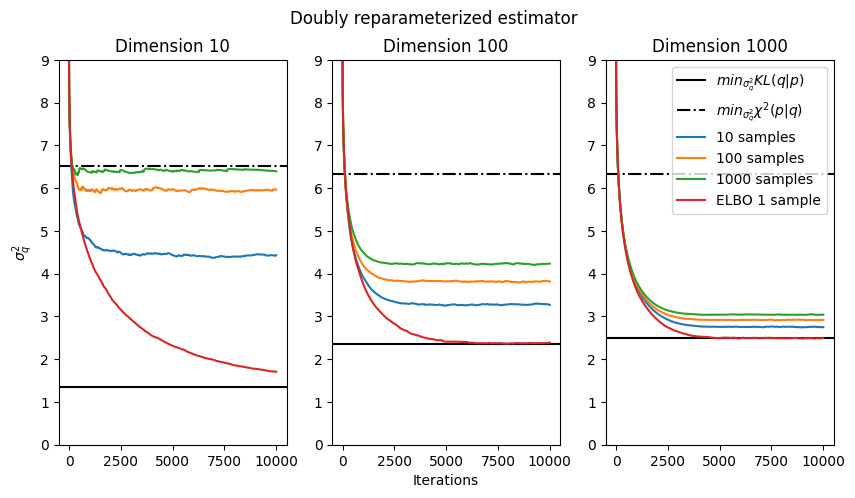

In [15]:
pairs = [tuple(map(int, key.split("-"))) for key in drep.keys()]

ds = sorted({d for d, _ in pairs})
ks = sorted({k for _, k in pairs})

f, axes = plt.subplots(1, len(ds), figsize=(10,5))
f.suptitle("Doubly reparameterized estimator")
for i, d in enumerate(ds):
    # v = 0.2 + 9.8 * (torch.arange(d)+1)/d
    v = torch.linspace(0.2, 10.0, d)
    axes[i].axhline(y=min_klqp(v), color='black', linestyle='-', label=r"$min_{\sigma_q^2} KL(q|p)$")
    axes[i].axhline(y=min_chi2(v), color='black', linestyle='-.', label=r"$min_{\sigma_q^2} \chi^2(p|q)$")
    
    for j, k in enumerate(ks):
        axes[i].plot(drep[f"{d}-{k}"], label=f"{k} samples")
    axes[i].plot(elbo[f"{d}"], label=f"ELBO 1 sample")
    axes[i].set_ylim(0, 9)
    axes[i].set_title(f"Dimension {d}")
plt.legend()
axes[0].set_ylabel(r"$\sigma^2_q$")
axes[1].set_xlabel("Iterations")
plt.show()

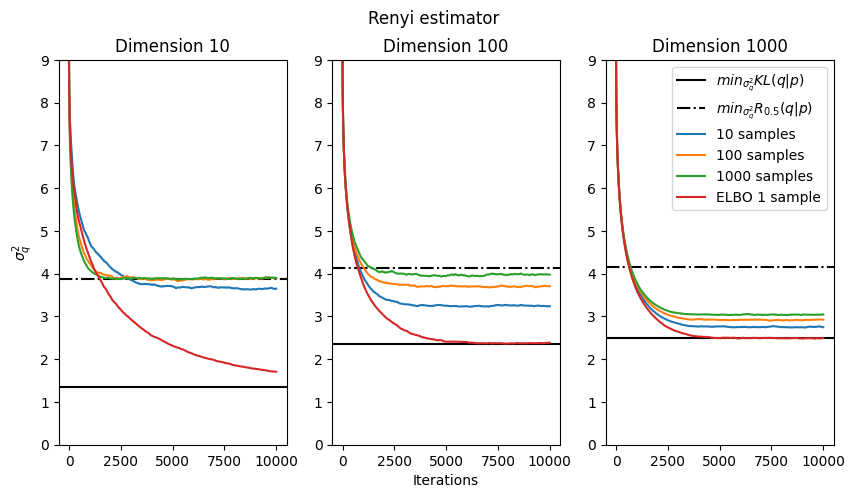

In [16]:
pairs = [tuple(map(int, key.split("-"))) for key in renyi.keys()]

ds = sorted({d for d, _ in pairs})
ks = sorted({k for _, k in pairs})

f, axes = plt.subplots(1, len(ds), figsize=(10,5))
f.suptitle("Renyi estimator")
for i, d in enumerate(ds):
    # v = 0.2 + 9.8 * (torch.arange(d)+1)/d
    v = torch.linspace(0.2, 10.0, d)
    axes[i].axhline(y=min_klqp(v), color='black', linestyle='-', label=r"$min_{\sigma_q^2} KL(q|p)$")
    axes[i].axhline(y=min_renyi(v), color='black', linestyle='-.', label=r"$min_{\sigma_q^2} R_{0.5}(q|p)$")
    
    for j, k in enumerate(ks):
        axes[i].plot(renyi[f"{d}-{k}"], label=f"{k} samples")
    axes[i].plot(elbo[f"{d}"], label=f"ELBO 1 sample")
    axes[i].set_ylim(0, 9)
    axes[i].set_title(f"Dimension {d}")
plt.legend()
axes[0].set_ylabel(r"$\sigma^2_q$")
axes[1].set_xlabel("Iterations")
plt.show()